# Data preprocessing and imputation

Real price data is rarely clean. Assets list partway through the window (leading gaps), trade
halts and stale quotes leave flat or missing stretches, names get delisted (trailing gaps), and
exchanges keep different holiday calendars so timestamps do not line up. Feeding that straight
into an optimiser is a recipe for silent errors. `prices_to_returns` handles all of it in
one call, *before* it computes returns, through three cooperating controls:

  - `missing_col_percent` — drop any **asset** whose fraction of missing observations exceeds
    this threshold (too sparse to trust).
  - `missing_row_percent` — drop any **timestamp** whose fraction of missing values across assets
    exceeds this threshold (e.g. a misaligned holiday).
  - `impute_method` — fill the *remaining* gaps with an [`Impute`](https://github.com/invenia/Impute.jl)
    imputor before differencing prices into returns.

The order matters: filter the hopeless rows/columns first, then impute what is left, then compute
returns.

> **When to reach for this**
>
> Reach for these whenever the raw price table has missing values — newly listed or delisted
> assets, halted or stale prices, or non-overlapping trading calendars. The decision for each
> asset or date is *drop or fill*: drop what is too sparse to trust (`missing_*_percent`), fill
> what is recoverable (`impute_method`), and let `prices_to_returns` do both in one pass.

> **Impute.jl imputors**
>
> Imputation methods are [`Impute.jl`](https://github.com/invenia/Impute.jl) imputors passed via
> `impute_method`, so bring in `using Impute`. The two most useful for prices are
> `Impute.LOCF()` (last observation carried forward — the right model for a halt or stale quote,
> since it holds the last traded price) and `Impute.Interpolate()` (linear interpolation —
> natural for short gaps between two good prices).

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames, Statistics, Impute

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. A clean slice, then realistic damage

We start from the usual S&P 500 slice and deliberately injure it to mimic the messes above: one
asset that is mostly missing (a late lister we will want to drop), a halted block of one asset,
and scattered single-day gaps across the rest.

In [2]:
using CSV, TimeSeries

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
ts = timestamp(X)
nx = string.(colnames(X))
T, N = size(values(X))

vals = Matrix{Union{Float64, Missing}}(values(X))
vals[1:160, 3] .= missing                 # asset 3: mostly missing (late lister → drop)
vals[100:120, 2] .= missing               # asset 2: a ~3-week trading halt (fillable)
using StableRNGs
rng = StableRNG(42)
for _ in 1:60                              # scattered single-day gaps elsewhere
    vals[rand(rng, 1:T), rand(rng, 4:N)] = missing
end
Xmiss = TimeArray(ts, vals, Symbol.(nx))

253×20 TimeSeries.TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 2021-12-28 to 2022-12-28
┌────────────┬─────────┬────────┬─────────┬─────────┬─────────┬────────┬────────
│            │ AAPL    │ AMD    │ BAC     │ BBY     │ CVX     │ GE     │ HD    ⋯
├────────────┼─────────┼────────┼─────────┼─────────┼─────────┼────────┼────────
│ 2021-12-28 │ 177.738 │ 153.15 │ missing │  92.981 │ 112.335 │ 73.953 │  390. ⋯
│ 2021-12-29 │ 177.827 │ 148.26 │ missing │  94.233 │ 111.757 │ 73.557 │ 395.0 ⋯
│ 2021-12-30 │ 176.657 │ 145.15 │ missing │  94.877 │ 111.264 │ 73.487 │ 394.1 ⋯
│ 2021-12-31 │ 176.033 │  143.9 │ missing │  94.924 │ 111.188 │ 73.309 │ 399.0 ⋯
│ 2022-01-03 │ 180.434 │ 150.24 │ missing │   95.41 │ 112.998 │ 74.682 │ 392.9 ⋯
│ 2022-01-04 │ 178.144 │ 144.42 │ missing │  98.231 │ 115.054 │ 77.111 │ 396.9 ⋯
│ 2022-01-05 │ 173.406 │ 136.15 │ missing │  96.232 │ 115.803 │ 77.111 │ 391.5 ⋯
│ 2022-01-06 │ 170.511 │ 136.23 │ missing │   96.12 │ 116.788 │ 77.561

## 2. Diagnose the missingness

Before deciding what to drop or fill, measure it. The per-column and per-row missing fractions
are exactly the quantities `missing_col_percent` and `missing_row_percent` threshold against.

In [3]:
col_missing = vec(mean(ismissing, vals; dims = 1))
worst_cols = sort(DataFrame(; asset = nx, missing_frac = col_missing), :missing_frac;
                  rev = true)
pretty_table(first(worst_cols, 6); formatters = [resfmt],
             title = "Missing fraction per asset (worst six)")

Missing fraction per asset (worst six)
┌────────┬──────────────┐
│  asset │ missing_frac │
│ String │     Float64? │
├────────┼──────────────┤
│    BAC │     63.241 % │
│    AMD │        8.3 % │
│    JPM │      5.138 % │
│    BBY │      2.767 % │
│    LLY │      2.372 % │
│    UNH │      2.372 % │
└────────┴──────────────┘


Asset 3 is missing ~64% of the time — there is no honest way to impute that, so it should be
dropped. Asset 2's halt and the scattered single-day gaps, by contrast, are short and
recoverable.

## 3. Drop the hopeless, keep the rest

`missing_col_percent = 0.5` drops any asset more than half missing (asset 3), while
`missing_row_percent = 0.5` would drop any date more than half missing across assets. With no
imputation yet, the kept assets still contain gaps, so we ask only how many assets survive the
filter.

In [4]:
rd_droponly = prices_to_returns(Xmiss; missing_col_percent = 0.5, missing_row_percent = 0.5,
                                impute_method = Impute.LOCF())
println("Assets kept after the 50% column filter: $(length(rd_droponly.nx)) of $N")

Assets kept after the 50% column filter: 19 of 20


## 4. Impute the survivors

The kept assets still have a halt and scattered gaps. We fill them with two different imputors
and compare. `Impute.LOCF()` carries the last observed *price* forward — so a halt becomes a flat
price stretch and therefore zero returns through the halt, which is the honest accounting for a
non-trading period. `Impute.Interpolate()` draws a straight line across the gap, spreading a
small constant return over the missing days.

In [5]:
rd_locf = prices_to_returns(Xmiss; missing_col_percent = 0.5, impute_method = Impute.LOCF())
rd_interp = prices_to_returns(Xmiss; missing_col_percent = 0.5,
                              impute_method = Impute.Interpolate())

pretty_table(DataFrame(; method = ["LOCF", "Interpolate"],
                       assets = [length(rd_locf.nx), length(rd_interp.nx)],
                       observations = [size(rd_locf.X, 1), size(rd_interp.X, 1)]);
             title = "Both imputors yield a complete returns matrix")

Both imputors yield a complete returns matrix
┌─────────────┬────────┬──────────────┐
│      method │ assets │ observations │
│      String │  Int64 │        Int64 │
├─────────────┼────────┼──────────────┤
│        LOCF │     20 │           92 │
│ Interpolate │     20 │           92 │
└─────────────┴────────┴──────────────┘


## 5. Straight into the pipeline

A cleaned `ReturnsResult` is just an ordinary one — it flows into the rest of the package
with no special handling. We solve a minimum-variance `MeanRisk` on the LOCF-imputed data
to confirm the preprocessing produced something usable end to end.

In [6]:
using Clarabel
slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
res = optimise(MeanRisk(; obj = MinimumRisk(),
                        opt = JuMPOptimiser(; pe = prior(EmpiricalPrior(), rd_locf),
                                            slv = slv)))
println("Min-variance solve on cleaned data: $(res.retcode), $(count(>(1e-6), res.w)) active names")

Min-variance solve on cleaned data: OptimisationSuccess
  res ┴ Dict{Any, Any}: Dict{Any, Any}()
, 8 active names


## 6. Visualising the damage

A heatmap of the missingness mask makes the structure obvious: the wide band is asset 3 (dropped
by the column filter), the short block is asset 2's halt, and the speckle is the scattered gaps
that imputation fills.

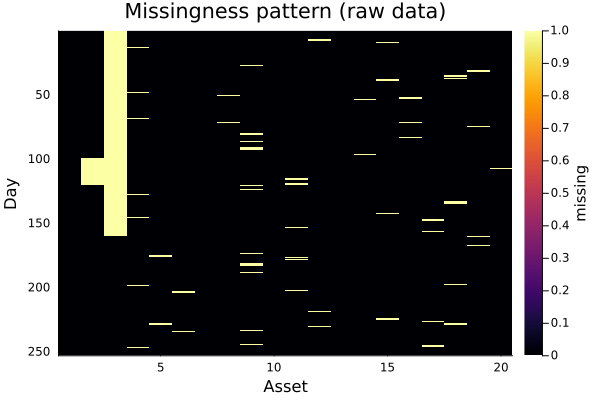

In [7]:
using StatsPlots, GraphRecipes
heatmap(1:N, 1:T, Float64.(ismissing.(vals)); xlabel = "Asset", ylabel = "Day",
        colorbar_title = "missing", title = "Missingness pattern (raw data)", yflip = true)

## Summary

`prices_to_returns` is the single entry point for cleaning price data:

  - `missing_col_percent` / `missing_row_percent` drop assets and dates that are too sparse to
    trust, before any returns are computed.
  - `impute_method` fills the recoverable gaps with an `Impute.jl` imputor — `Impute.LOCF()` for
    halts and stale quotes, `Impute.Interpolate()` for short gaps.
  - The result is an ordinary `ReturnsResult` that feeds the rest of the pipeline
    unchanged.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*